In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy import stats

wildcats = pd.read_csv('fbs_fbs_wildcats.csv')
run_concepts = pd.read_csv('run_concept_by_play.csv')
goal_line = pd.read_csv('goal_line.csv')

goal_line.loc[:, 'first_down_gained_numeric'] = goal_line['first_down_gained'].fillna(0)

plays = pd.merge(wildcats, run_concepts, on=['pff_game_id', 'pff_play_id'], how='left')

plays['goal_to_go'] = plays['yards_to_goal_line'] == plays['distance']
plays.loc[:, 'first_down_gained_numeric'] = plays['first_down_gained'].fillna(0)
# plays

C:\Users\bchm5\AppData\Local\Temp\ipykernel_25460\794240006.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  wildcats = pd.read_csv('fbs_fbs_wildcats.csv')


In [68]:
# goal_line[goal_line['hb_wildcat_run'] == 1].groupby('season').size()
goal_line['distance'].unique()

array([1, 2, 3, 0])

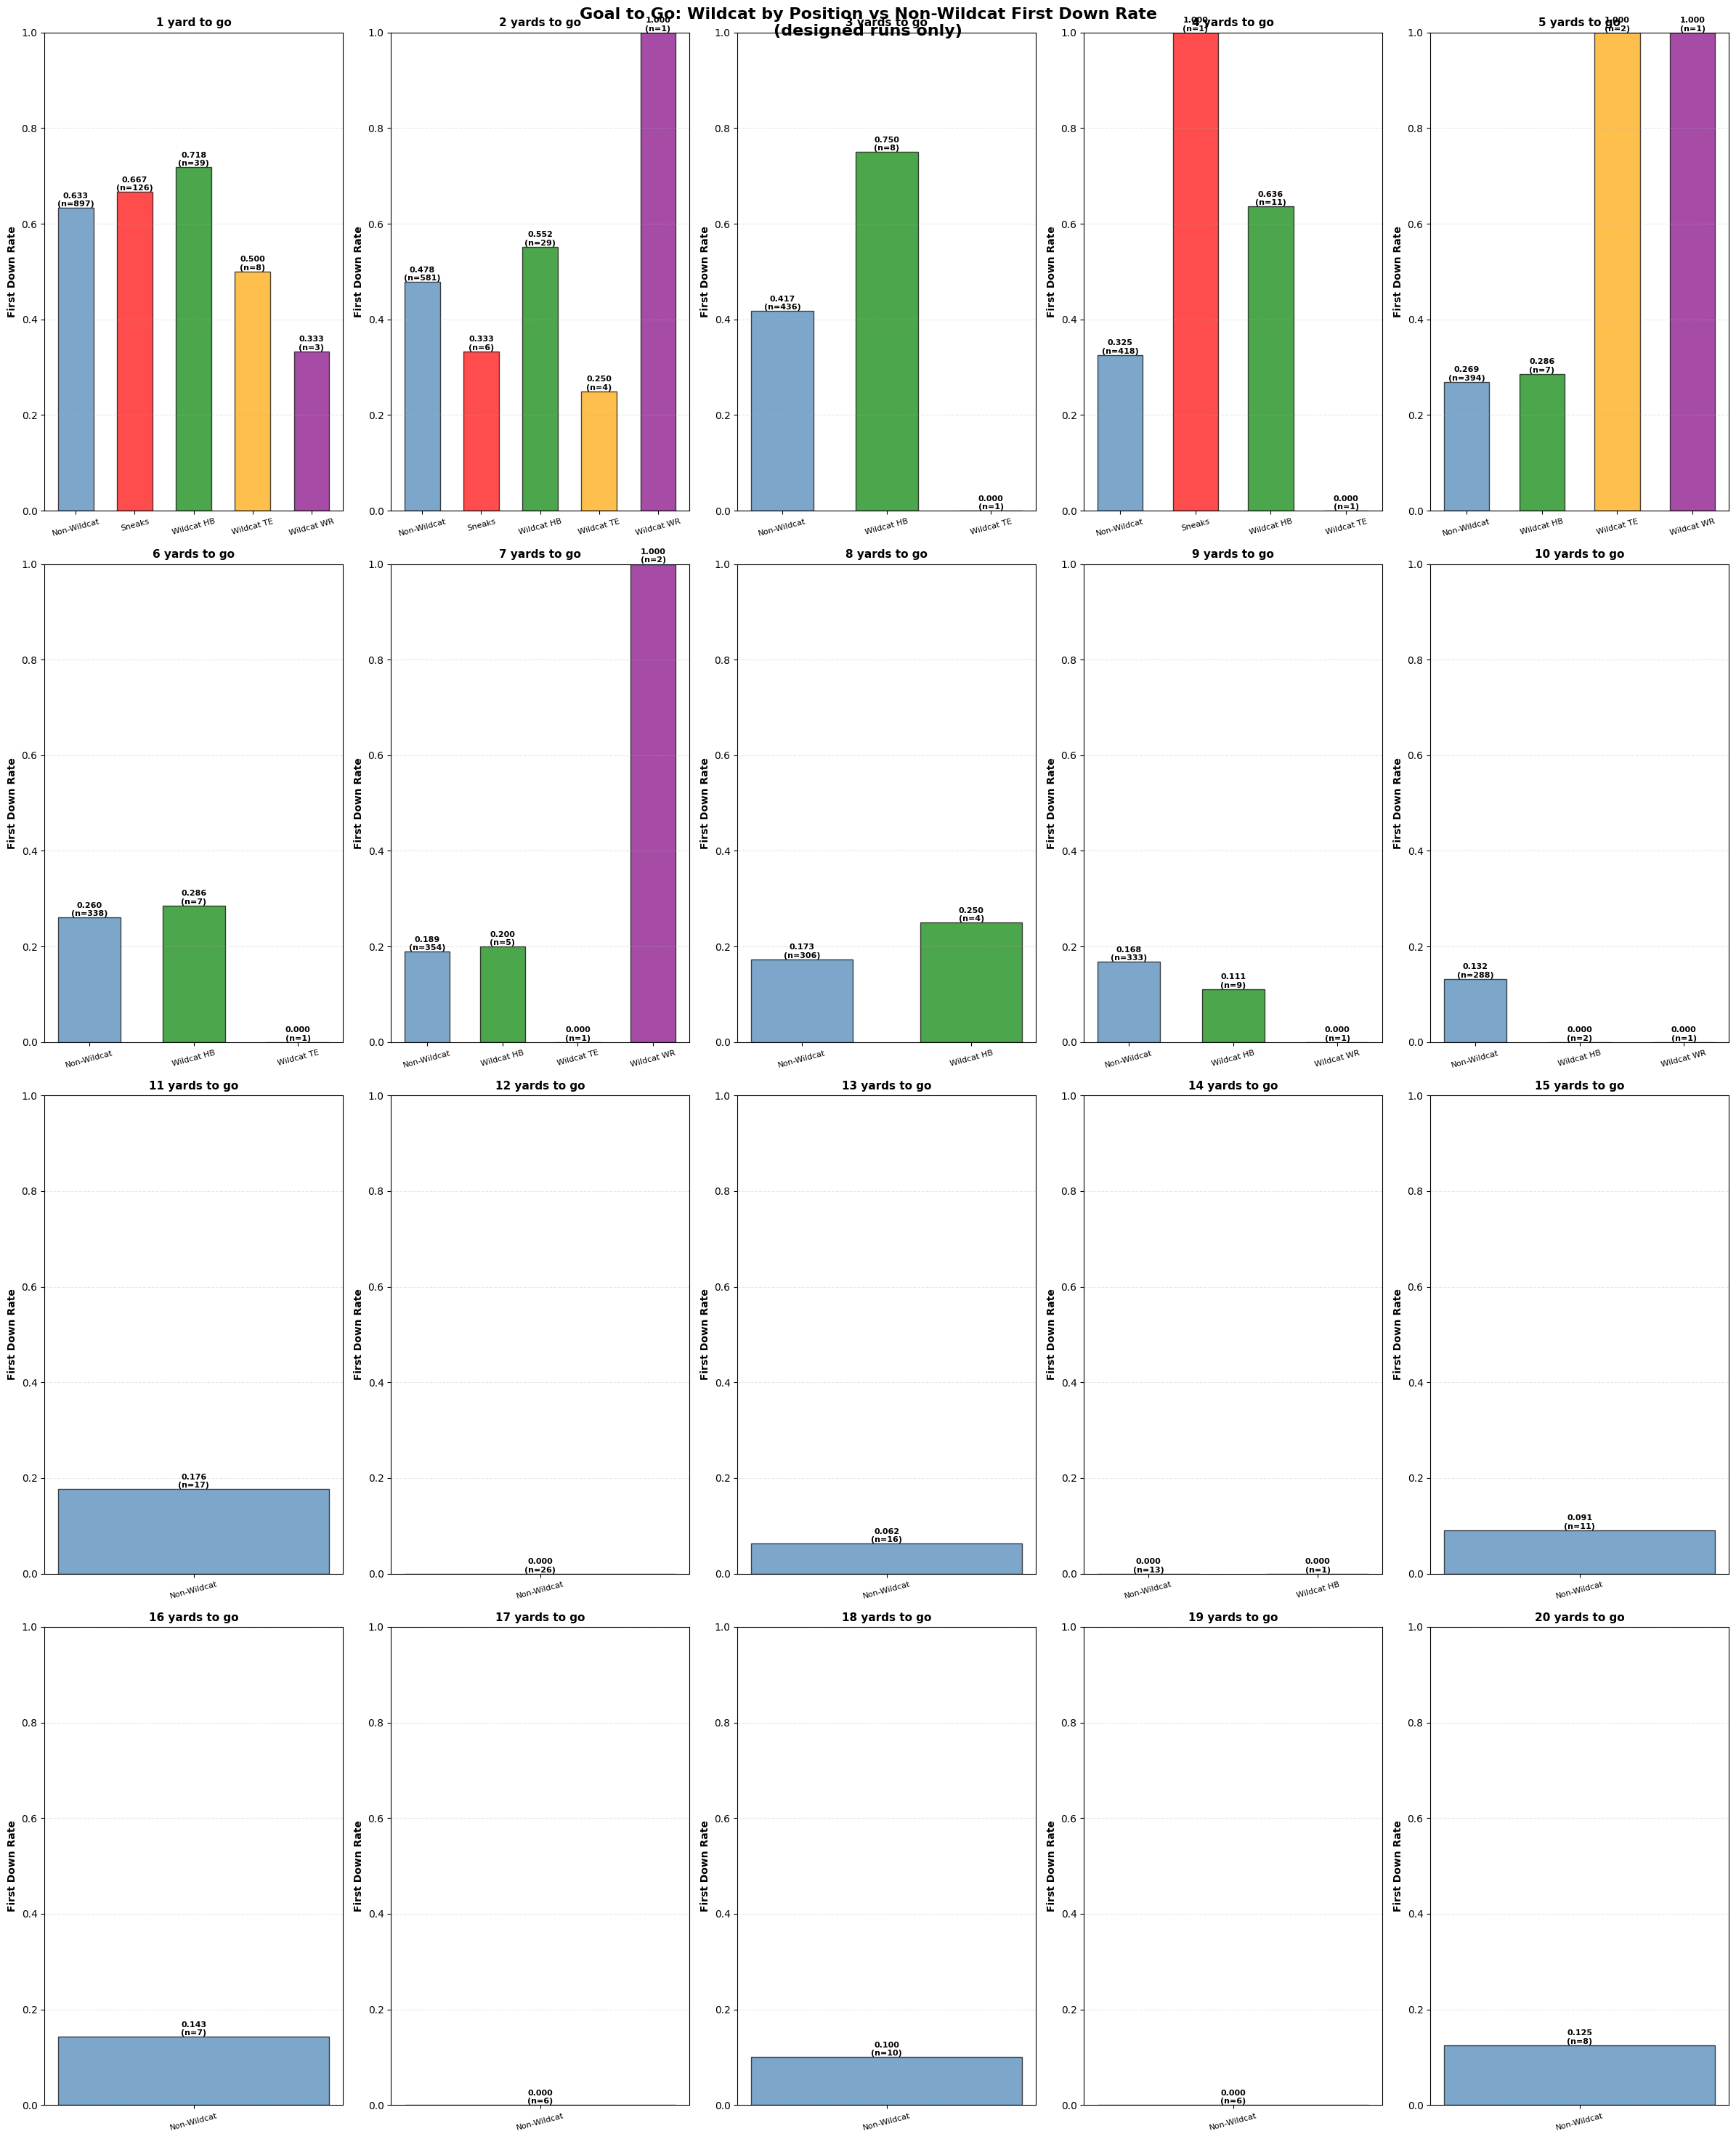

In [ ]:
plays['goal_to_go'] = plays['yards_to_goal_line'] == plays['distance']
plays.loc[:, 'first_down_gained_numeric'] = plays['first_down_gained'].fillna(0)

gtg = plays[
    (plays['goal_to_go'] == True) &
    (plays['play_type'] == 'designed run')
]

gtg_normal = gtg[(gtg['wildcat_play'] == 0) & gtg['primary_run_concept'] != 'SNEAK']
gtg_sneak = gtg[(gtg['wildcat_play'] == 0) & (gtg['primary_run_concept'] == 'SNEAK')]
gtg_hb = gtg[(gtg['wildcat_play'] == 1) & (gtg['wildcat_position'] == 'HB')]
gtg_te = gtg[(gtg['wildcat_play'] == 1) & (gtg['wildcat_position'] == 'TE')]
gtg_wr = gtg[(gtg['wildcat_play'] == 1) & (gtg['wildcat_position'] == 'WR')]

groups = {
    'Non-Wildcat': (gtg_normal, 'steelblue'),
    'Sneaks': (gtg_sneak, 'red'),
    'Wildcat HB':  (gtg_hb, 'green'),
    'Wildcat TE':  (gtg_te, 'orange'),
    'Wildcat WR':  (gtg_wr, 'purple'),
}

distances = sorted(gtg['distance'].unique())
distances = [d for d in distances]

fig, axes = plt.subplots(4, 5, figsize=(24, 30))
axes = axes.flatten()

for idx, dist in enumerate(distances[:20]):
    ax = axes[idx]
    valid_groups = {k: v for k, v in groups.items()
                    if len(v[0][v[0]['distance'] == dist]) >= 1}

    for i, (label, (df, color)) in enumerate(valid_groups.items()):
        dist_df = df[df['distance'] == dist]
        fd_rate = dist_df['first_down_gained_numeric'].mean()
        n = len(dist_df)

        ax.bar(i, fd_rate, width=0.6, color=color, alpha=0.7, edgecolor='black')
        ax.text(i, fd_rate, f"{fd_rate:.3f}\n(n={n:,})",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(range(len(valid_groups)))
    ax.set_xticklabels(list(valid_groups.keys()), rotation=15, fontsize=8)
    ax.set_title(f'{dist} yard{"s" if dist > 1 else ""} to go', fontweight='bold', fontsize=11)
    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

for j in range(len(distances), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Goal to Go: Wildcat by Position vs Non-Wildcat First Down Rate\n(designed runs only)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
goal_line['distance'].unique()

array([1, 2, 3, 0])

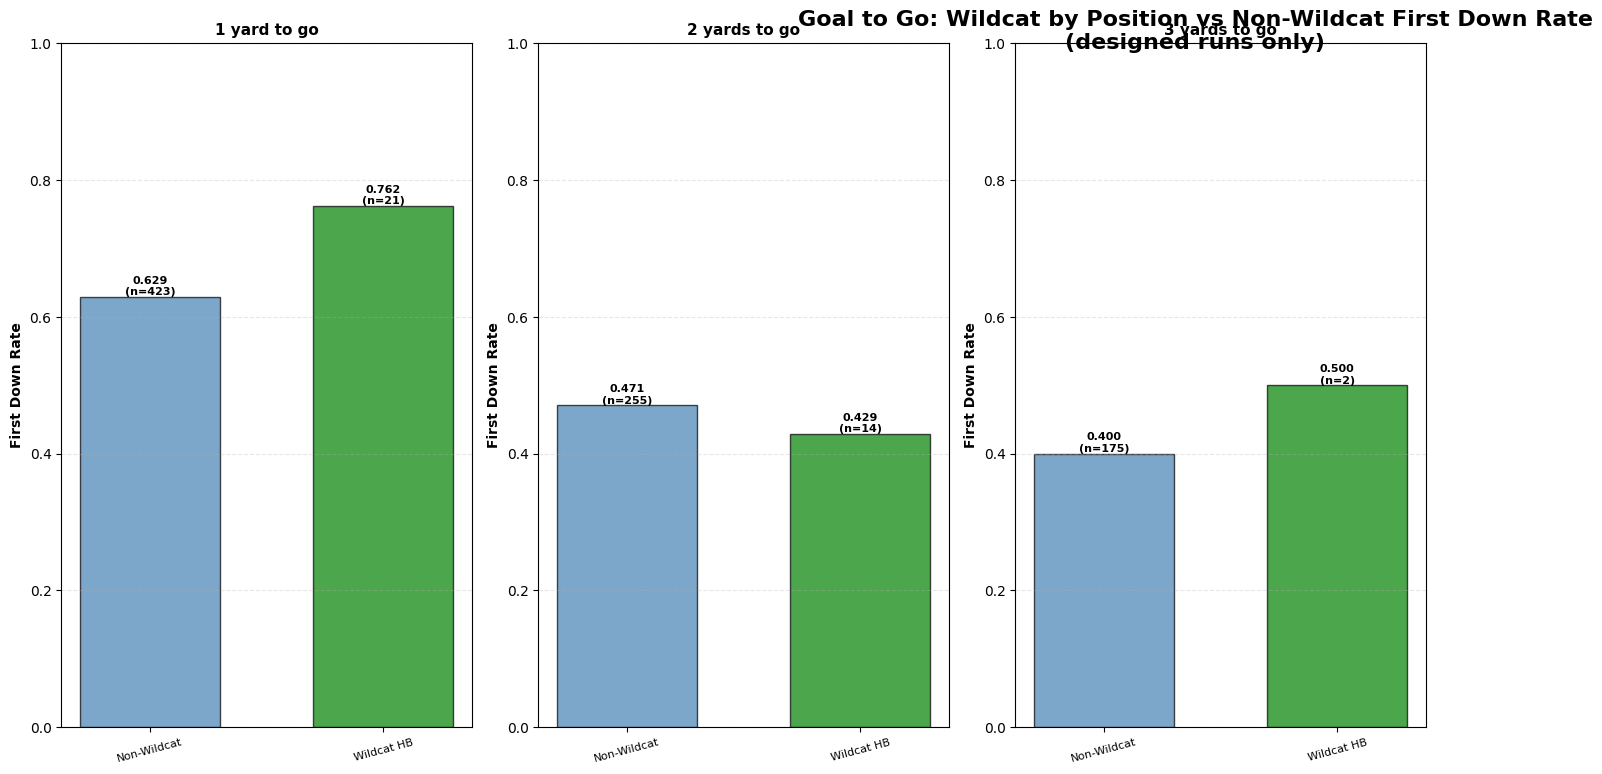

In [72]:
gtg = goal_line[
    (goal_line['play_type'] == 'designed run') &
    (goal_line['season'] == 2025)
]

gtg_normal = gtg[(gtg['hb_wildcat_run'] == 0) & gtg['primary_run_concept'] != 'SNEAK']
gtg_sneak = gtg[(gtg['hb_wildcat_run'] == 0) & (gtg['primary_run_concept'] == 'SNEAK')]
gtg_hb = gtg[(gtg['hb_wildcat_run'] == 1)]

groups = {
    'Non-Wildcat': (gtg_normal, 'steelblue'),
    'Sneaks': (gtg_sneak, 'red'),
    'Wildcat HB':  (gtg_hb, 'green'),
}

distances = sorted(gtg['yards_to_goal_line'].unique())
distances = [d for d in distances]

fig, axes = plt.subplots(4, 5, figsize=(24, 30))
axes = axes.flatten()

for idx, dist in enumerate(distances[:20]):
    ax = axes[idx]
    valid_groups = {k: v for k, v in groups.items()
                    if len(v[0][v[0]['distance'] == dist]) >= 1}

    for i, (label, (df, color)) in enumerate(valid_groups.items()):
        dist_df = df[df['distance'] == dist]
        fd_rate = dist_df['first_down_gained_numeric'].mean()
        n = len(dist_df)

        ax.bar(i, fd_rate, width=0.6, color=color, alpha=0.7, edgecolor='black')
        ax.text(i, fd_rate, f"{fd_rate:.3f}\n(n={n:,})",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(range(len(valid_groups)))
    ax.set_xticklabels(list(valid_groups.keys()), rotation=15, fontsize=8)
    ax.set_title(f'{dist} yard{"s" if dist > 1 else ""} to go', fontweight='bold', fontsize=11)
    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

for j in range(len(distances), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Goal to Go: Wildcat by Position vs Non-Wildcat First Down Rate\n(designed runs only)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# print(plays.columns.tolist())
plays['play_type'].value_counts()


play_type
designed run    57745
dropback        50325
kickoff          8609
no play          7504
punt             6649
extra point      4774
field goal       2573
Name: count, dtype: int64

In [46]:
gtg_clean = gtg[gtg['garbage_time'] == 0]

gtg_short = gtg_clean[gtg_clean['yards_to_goal_line'] <= 3]

hb_wildcat = gtg_short[(gtg_short['wildcat_play'] == 1) & (gtg_short['wildcat_position'] == 'HB')]['first_down_gained_numeric']
normal_runs = gtg_short[(gtg_short['wildcat_play'] == 0) & (gtg_short['primary_run_concept'] != 'SNEAK')]['first_down_gained_numeric']

t_stat, p_value = stats.ttest_ind(hb_wildcat, normal_runs)

print(f"HB Wildcat:   mean={hb_wildcat.mean()}, n={len(hb_wildcat)}")
print(f"Normal Runs:  mean={normal_runs.mean()}, n={len(normal_runs)}")
print(f"T:  {t_stat}")
print(f"P:  {p_value}")

'''Yes significant goddam'''

HB Wildcat:   mean=0.6533333333333333, n=75
Normal Runs:  mean=0.524198617221873, n=1591
T:  2.191543112840503
P:  0.02855069814950183


'Yes significant goddam'

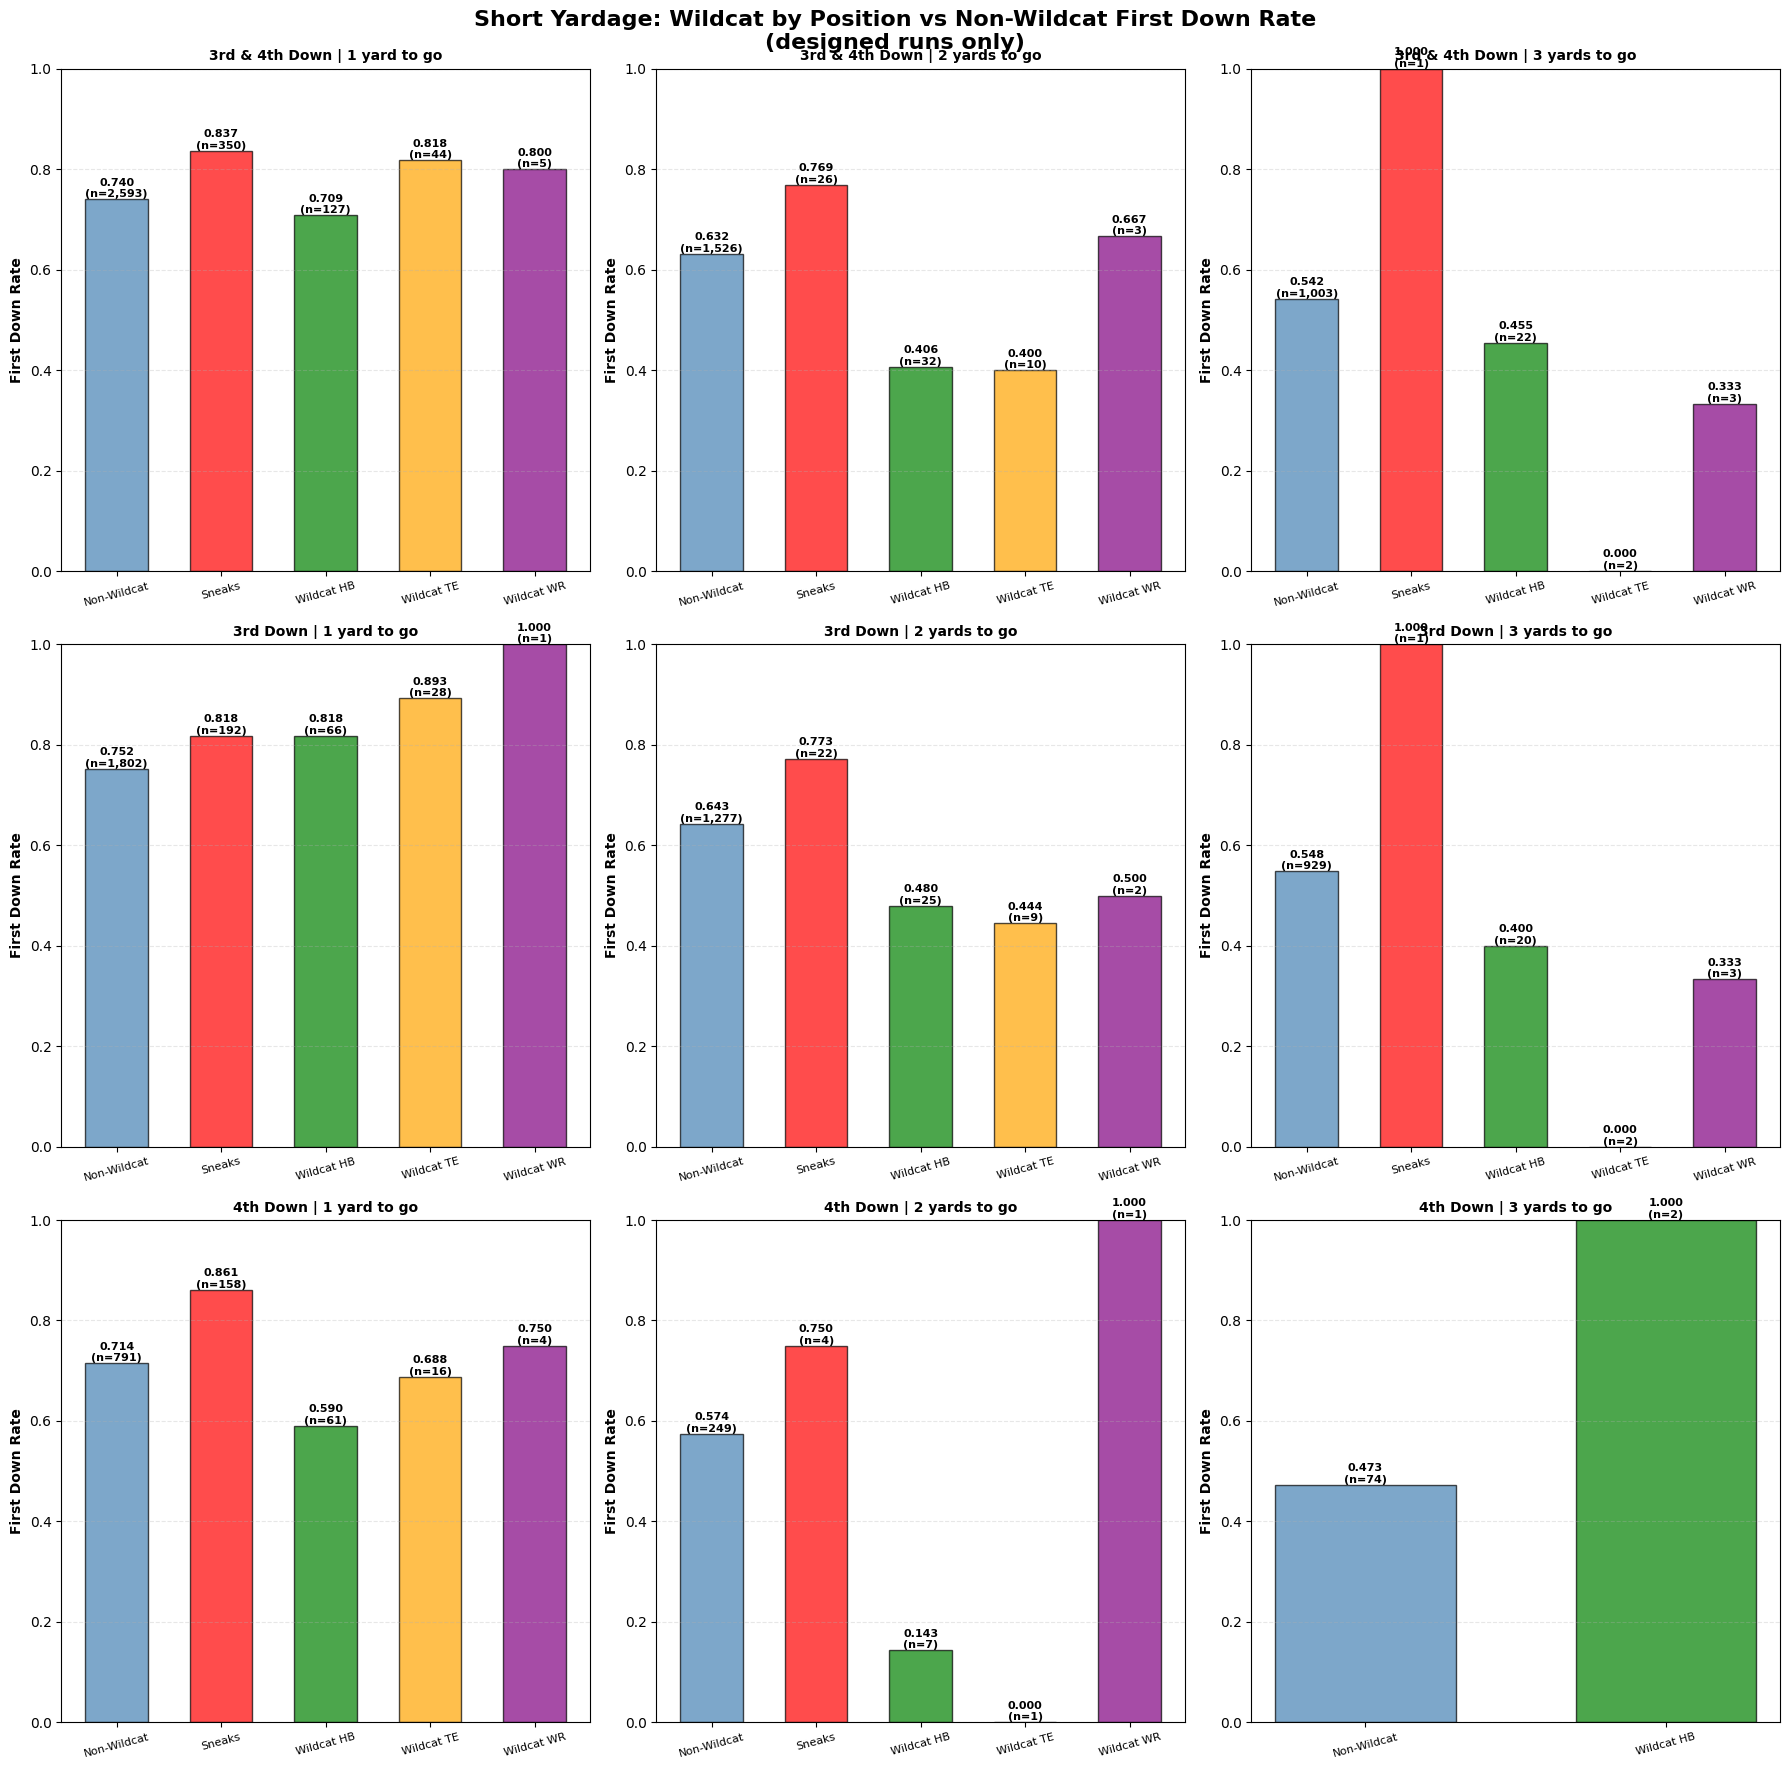

In [49]:
plays.loc[:, 'first_down_gained_numeric'] = plays['first_down_gained'].fillna(0)

base = plays[
    (plays['play_type'] == 'designed run') &
    (plays['distance'] < 4)
]

down_filters = {
    '3rd & 4th Down': base[base['down'].isin([3, 4])],
    '3rd Down':       base[base['down'] == 3],
    '4th Down':       base[base['down'] == 4],
}

distances = sorted(base['distance'].unique())

fig, axes = plt.subplots(3, len(distances), figsize=(6 * len(distances), 18))

for row_idx, (down_label, data) in enumerate(down_filters.items()):
    normal = data[(data['wildcat_play'] == 0) & (data['primary_run_concept'] != 'SNEAK')]
    sneak  = data[(data['wildcat_play'] == 0) & (data['primary_run_concept'] == 'SNEAK')]
    hb     = data[(data['wildcat_play'] == 1) & (data['wildcat_position'] == 'HB')]
    te     = data[(data['wildcat_play'] == 1) & (data['wildcat_position'] == 'TE')]
    wr     = data[(data['wildcat_play'] == 1) & (data['wildcat_position'] == 'WR')]

    groups = {
        'Non-Wildcat': (normal, 'steelblue'),
        'Sneaks':      (sneak, 'red'),
        'Wildcat HB':  (hb, 'green'),
        'Wildcat TE':  (te, 'orange'),
        'Wildcat WR':  (wr, 'purple'),
    }

    for col_idx, dist in enumerate(distances):
        ax = axes[row_idx, col_idx]
        valid_groups = {k: v for k, v in groups.items()
                        if len(v[0][v[0]['distance'] == dist]) >= 1}

        for i, (label, (df, color)) in enumerate(valid_groups.items()):
            dist_df = df[df['distance'] == dist]
            fd_rate = dist_df['first_down_gained_numeric'].mean()
            n = len(dist_df)

            ax.bar(i, fd_rate, width=0.6, color=color, alpha=0.7, edgecolor='black')
            ax.text(i, fd_rate, f"{fd_rate:.3f}\n(n={n:,})",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

        ax.set_xticks(range(len(valid_groups)))
        ax.set_xticklabels(list(valid_groups.keys()), rotation=15, fontsize=8)
        ax.set_title(f'{down_label} | {dist} yard{"s" if dist > 1 else ""} to go',
                     fontweight='bold', fontsize=10)
        ax.set_ylabel('First Down Rate', fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Short Yardage: Wildcat by Position vs Non-Wildcat First Down Rate\n(designed runs only)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
gtg_clean = gtg[gtg['garbage_time'] == 0]

gtg_short = gtg_clean[gtg_clean['yards_to_goal_line'] <= 3]

hb_wildcat = gtg_short[(gtg_short['wildcat_play'] == 1) & (gtg_short['wildcat_position'] == 'HB')]['first_down_gained_numeric']
normal_runs = gtg_short[(gtg_short['wildcat_play'] == 0) & (gtg_short['primary_run_concept'] != 'SNEAK')]['first_down_gained_numeric']

t_stat, p_value = stats.ttest_ind(hb_wildcat, normal_runs)

print(f"HB Wildcat:   mean={hb_wildcat.mean()}, n={len(hb_wildcat)}")
print(f"Normal Runs:  mean={normal_runs.mean()}, n={len(normal_runs)}")
print(f"T:  {t_stat}")
print(f"P:  {p_value}")

'''Yes significant goddam'''

In [79]:
from scipy import stats

categorical_columns = [
    'motion', 'shift', 'unbalanced', 'trick_look', 'no_huddle', 'tempo',
    'goal_to_go', 'garbage_time', 'two_minute', 'blitz_dog', 'stunt',
    'mug_look', 'defensive_line_shift', 'run_pass_option', 'draw',
    'box_players_count', 'safety_count', 'down', 'hash',
    'primary_run_concept', 'intended_poa', 'defensive_front_name', 'def_package'
]

sig_dict = {}

wildcat_runs = goal_line[goal_line['hb_wildcat_run'] == 1].copy()

for col in categorical_columns:
    if col not in wildcat_runs.columns:
        print(f"Skipping {col} — not in dataframe")
        continue

    unique_vals = wildcat_runs[col].dropna().unique()

    if len(unique_vals) < 2:
        print(f"Skipping {col} — only 1 unique value")
        continue

    groups = [wildcat_runs[wildcat_runs[col] == v]['first_down_gained_numeric'].dropna()
              for v in unique_vals]
    groups = [g for g in groups if len(g) >= 2]

    if len(groups) < 2:
        print(f"Skipping {col} — insufficient sample sizes")
        continue

    print(f"\n--- {col} ---")
    for val, group in zip(unique_vals, groups):
        print(f"  {val}: mean={group.mean():.3f} (n={len(group)})")

    if len(unique_vals) == 2:
        # binary — t-test
        t_stat, p_value = stats.ttest_ind(groups[0], groups[1])
        test_used = 't-test'
        sig_dict[col] = {
            'test': test_used,
            't_stat': t_stat,
            'p_value': p_value,
            'significant': p_value < 0.05,
        }
        print(f"  T-statistic: {t_stat:.3f}")
    else:
        # 3+ groups — one-way ANOVA
        f_stat, p_value = stats.f_oneway(*groups)
        test_used = 'ANOVA'
        sig_dict[col] = {
            'test': test_used,
            'f_stat': f_stat,
            'p_value': p_value,
            'significant': p_value < 0.05,
        }
        print(f"  F-statistic: {f_stat:.3f}")

    print(f"  P-value:     {p_value:.3f}")
    print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")

sig_df = pd.DataFrame(sig_dict).T.sort_values('p_value')
print("\n--- Summary (sorted by p-value) ---")
print(sig_df)


--- motion ---
  1: mean=0.603 (n=68)
  0: mean=0.569 (n=72)
  T-statistic: 0.399
  P-value:     0.690
  Significant: No (α=0.05)

--- shift ---
  0: mean=0.587 (n=121)
  1: mean=0.579 (n=19)
  T-statistic: 0.064
  P-value:     0.949
  Significant: No (α=0.05)

--- unbalanced ---
  0: mean=0.634 (n=112)
  1: mean=0.393 (n=28)
  T-statistic: 2.345
  P-value:     0.020
  Significant: Yes (α=0.05)

--- trick_look ---
  1: mean=0.578 (n=116)
  0: mean=0.625 (n=24)
  T-statistic: -0.426
  P-value:     0.670
  Significant: No (α=0.05)
Skipping no_huddle — only 1 unique value

--- tempo ---
  0: mean=0.577 (n=137)
  1: mean=1.000 (n=3)
  T-statistic: -1.473
  P-value:     0.143
  Significant: No (α=0.05)

--- goal_to_go ---
  1: mean=0.627 (n=126)
  0: mean=0.214 (n=14)
  T-statistic: 3.050
  P-value:     0.003
  Significant: Yes (α=0.05)
Skipping garbage_time — only 1 unique value

--- two_minute ---
  0: mean=0.579 (n=133)
  2: mean=0.714 (n=7)
  T-statistic: -0.705
  P-value:     0.482
  

c:\Users\bchm5\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
from scipy.stats import tukey_hsd
from itertools import combinations
from itertools import combinations

groups_dict = {v: wildcat_runs[wildcat_runs['primary_run_concept'] == v]['first_down_gained_numeric'].dropna()
               for v in wildcat_runs['primary_run_concept'].dropna().unique()
               if len(wildcat_runs[wildcat_runs['primary_run_concept'] == v]) >= 2}

labels = list(groups_dict.keys())
groups = list(groups_dict.values())

result = stats.tukey_hsd(*groups)

print(f"{'Concept A':<20} {'Concept B':<20} {'p-value':<12} {'Significant'}")
print("-" * 65)
for i, j in combinations(range(len(labels)), 2):
    p = result.pvalue[i][j]
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{labels[i]:<20} {labels[j]:<20} {p:<12.3f} {sig}")

Concept A            Concept B            p-value      Significant
-----------------------------------------------------------------
POWER                MAN                  0.192        No
POWER                INSIDE ZONE          0.535        No
POWER                OUTSIDE ZONE         0.008        Yes
POWER                COUNTER              0.898        No
POWER                PULL LEAD            0.351        No
POWER                TRICK                0.192        No
MAN                  INSIDE ZONE          0.999        No
MAN                  OUTSIDE ZONE         0.339        No
MAN                  COUNTER              0.984        No
MAN                  PULL LEAD            1.000        No
MAN                  TRICK                0.675        No
INSIDE ZONE          OUTSIDE ZONE         0.240        No
INSIDE ZONE          COUNTER              1.000        No
INSIDE ZONE          PULL LEAD            0.998        No
INSIDE ZONE          TRICK                0.587       

In [88]:
for id in wildcat_runs['pff_play_id']:
    print(str(id) + ', ', end="")

6820849, 6875853, 6736372, 6650326, 6637565, 6637584, 6655731, 6747887, 6374143, 6954835, 6956620, 6374890, 6374912, 6816292, 6445703, 6955529, 6571884, 6684071, 6831123, 6912578, 6831573, 6783532, 6597552, 6789602, 6870355, 6731690, 6871611, 6913701, 6551296, 6819135, 6505760, 6689422, 6824488, 6745112, 6556741, 6787623, 6902540, 6613480, 6438687, 5353320, 5743231, 5890851, 4299079, 4492073, 4492124, 4492144, 3900568, 4493187, 4830540, 4066717, 3908068, 5256591, 4694103, 4832007, 6171827, 5874600, 5391069, 5324120, 5287688, 4784060, 5260930, 4269665, 5184790, 4548011, 4861648, 5310170, 5389544, 5211022, 5211079, 4223655, 4344708, 6174980, 4344775, 4957076, 4751247, 5718320, 4236857, 5080679, 5185105, 4036513, 5290147, 4235448, 4904635, 5172105, 5385944, 5518189, 5322785, 5914203, 5261059, 6203132, 6203861, 4660982, 6161604, 4036455, 4036694, 4260562, 5190672, 6170113, 4238901, 5384773, 6125326, 5106642, 4488006, 4542134, 4093819, 4224643, 5472533, 5473300, 5420668, 5832052, 5499469, 5

In [121]:
# reconstruct binary arrays from rates and sample sizes
group1 = np.array([1]*22 + [0]*5)  
group2 = np.array([1]*29 + [0]*11) 
group3 = np.array([1]*38 + [0]*33) 

f_stat, p_value = stats.f_oneway(group1, group2, group3)

print(f"Fuckshit: {22/27:.3f} (n=22)")
print(f"QB Present: {29/40:.3f} (n=41)")
print(f"Normal Wildcat: {38/71:.3f} (n=77)")
print(f"\nF-statistic: {f_stat:.3f}")
print(f"P-value:     {p_value:.3f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")

# tukey for pairwise
result = stats.tukey_hsd(group1, group2, group3)
labels = ['Fuckshit (0.727)', 'QB Present (0.683)', 'Normal Wildcat (0.532)']
print(f"\n{'Pair':<40} {'p-value':<12} {'Significant'}")
print("-" * 60)
for i, j in combinations(range(3), 2):
    p = result.pvalue[i][j]
    print(f"{labels[i]} vs {labels[j]:<15} {p:<12.3f} {'Yes' if p < 0.05 else 'No'}")


# combine groups 1 and 2
combined_12 = np.array([1]*51 + [0]*16)  # 16+28=44 successes, 6+13=19 failures
group3 = np.array([1]*38 + [0]*33)

t_stat, p_value = stats.ttest_ind(combined_12, group3)

print(f"\n\nGroups 1+2: {44/63:.3f} (n=63)")
print(f"Group 3:    {41/77:.3f} (n=77)")
print(f"\nT-statistic: {t_stat:.3f}")
print(f"P-value:     {p_value:.3f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")

Fuckshit: 0.815 (n=22)
QB Present: 0.725 (n=41)
Normal Wildcat: 0.535 (n=77)

F-statistic: 4.295
P-value:     0.016
Significant: Yes (α=0.05)

Pair                                     p-value      Significant
------------------------------------------------------------
Fuckshit (0.727) vs QB Present (0.683) 0.723        No
Fuckshit (0.727) vs Normal Wildcat (0.532) 0.025        Yes
QB Present (0.683) vs Normal Wildcat (0.532) 0.105        No


Groups 1+2: 0.698 (n=63)
Group 3:    0.532 (n=77)

T-statistic: 2.832
P-value:     0.005
Significant: Yes (α=0.05)


In [126]:
present_total = [6875853, 6650326, 6637565, 6374143, 6956620, 6374890, 6374912, 6816292, 6955529, 6571884, 6684071, 6831123, 6831573, 6597552, 6789602, 6870355, 6731690, 6871611, 6913701, 6505760, 6689422, 6787623, 6902540, 6438687, 
                 4299079, 5261059, 4260562, 5384773, 6125326, 5499469, 5133396, 6198178, 6199119, 4684886, 5259620, 6147439, 4733489, 6251545, 4238901, 6170113]
present_success = [6875853, 6650326, 6637565, 6956620, 6374912, 6816292, 6955529, 6684071, 6831573, 6597552, 6789602, 6913701, 6505760, 6689422, 6902540, 6438687, 4299079, 5261059, 4260562, 5384773, 6125326, 5499469, 5133396, 6198178, 6199119, 
                   4684886, 6147439, 4238901, 6170113]

fuckshit_total = [6736372, 6747887, 6912578, 5890851, 4493187, 3908068, 4784060, 5718320, 5322785, 4542134, 5467364, 5945472, 4306474, 4234569, 5278711, 5184790, 5389544, 4957076, 5290147, 5172105, 5385944, 4224643, 5324120, 5185105, 4036455,
                  5872405, 3930757]
fuckshit_success = [6736372, 6747887, 6912578, 5890851, 4493187, 4784060, 5718320, 5322785, 5467364, 4234569, 5184790, 5389544, 4957076, 5290147, 5172105, 5385944, 4224643, 5324120, 5185105, 4036455, 5872405, 3930757]

normal_total = [6820849, 6655731, 6445703, 6783532, 6551296, 6819135, 6824488, 6745112, 6556741, 6613480, 5353320, 5743231, 4492073, 4492124, 4492144, 3900568, 4830540, 4066717, 5256591, 4694103, 4832007, 6171827, 5874600, 5391069, 
                5287688, 5260930, 4269665, 4548011, 4861648, 5310170, 5211022, 5211079, 4223655, 4344708, 6174980, 4344775, 4751247, 4236857, 5080679, 4036513, 4235448, 4904635, 
                5518189, 5914203, 6203132, 6203861, 4660982, 6161604, 4036694, 5190672, 5106642, 4488006, 4093819, 5472533, 5473300, 5420668, 5832052, 4445498, 4123965, 4271709, 5464253, 5316190, 
                6210839, 5283268, 5427843, 3930643, 5514947, 4303886, 5342509, 6021188, 4897738]
normal_success = [6820849, 6655731, 6783532, 6824488, 6745112, 6556741, 4830540, 4066717, 5256591, 4694103, 4832007, 5874600, 5391069, 4861648, 5310170, 5211079, 5080679, 4036513, 4235448, 
                  4904635, 5518189, 5914203, 6203132, 6203861, 4660982, 6161604, 4036694, 5106642, 4093819, 5420668, 4445498, 4271709, 5464253, 5316190, 6210839, 5427843, 4303886, 5342509]


present_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(present_total)].copy()
fuckshit_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(fuckshit_total)].copy()
normal_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(normal_total)].copy()

present_success_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(present_success)].copy()
fuckshit_success_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(fuckshit_success)].copy()
normal_success_df = wildcat_runs[wildcat_runs['pff_play_id'].isin(normal_success)].copy()

present_df['wildcat_decision'] = 'present'
fuckshit_df['wildcat_decision'] = 'fuckshit'
normal_df['wildcat_decision'] = 'normal'

present_success_df['wildcat_decision'] = 'present'
fuckshit_success_df['wildcat_decision'] = 'fuckshit'
normal_success_df['wildcat_decision'] = 'normal'

combined_df = pd.concat([present_df, fuckshit_df, normal_df], ignore_index=True)
combined_success_df = pd.concat([present_success_df, fuckshit_success_df, normal_success_df], ignore_index=True)

print(f"Present:    {len(present_df)} total, {len(present_success_df)} success")
print(f"Fuckshit:   {len(fuckshit_df)} total, {len(fuckshit_success_df)} success")
print(f"Normal:     {len(normal_df)} total, {len(normal_success_df)} success")
print(f"All Wildcat:{len(combined_df)} total, {len(combined_success_df)} success")

Present:    40 total, 29 success
Fuckshit:   27 total, 22 success
Normal:     71 total, 38 success
All Wildcat:138 total, 89 success


In [122]:
print(f"Present: {len(present_success)}/{len(present_total)}={round(len(present_success)/len(present_total), 3)}")
print(f"Fuckshit: {len(fuckshit_success)}/{len(fuckshit_total)}={round(len(fuckshit_success)/len(fuckshit_total), 3)}")
print(f"Normal: {len(normal_success)}/{len(normal_total)}={round(len(normal_success)/len(normal_total), 3)}")

Present: 29/40=0.725
Fuckshit: 22/27=0.815
Normal: 38/71=0.535


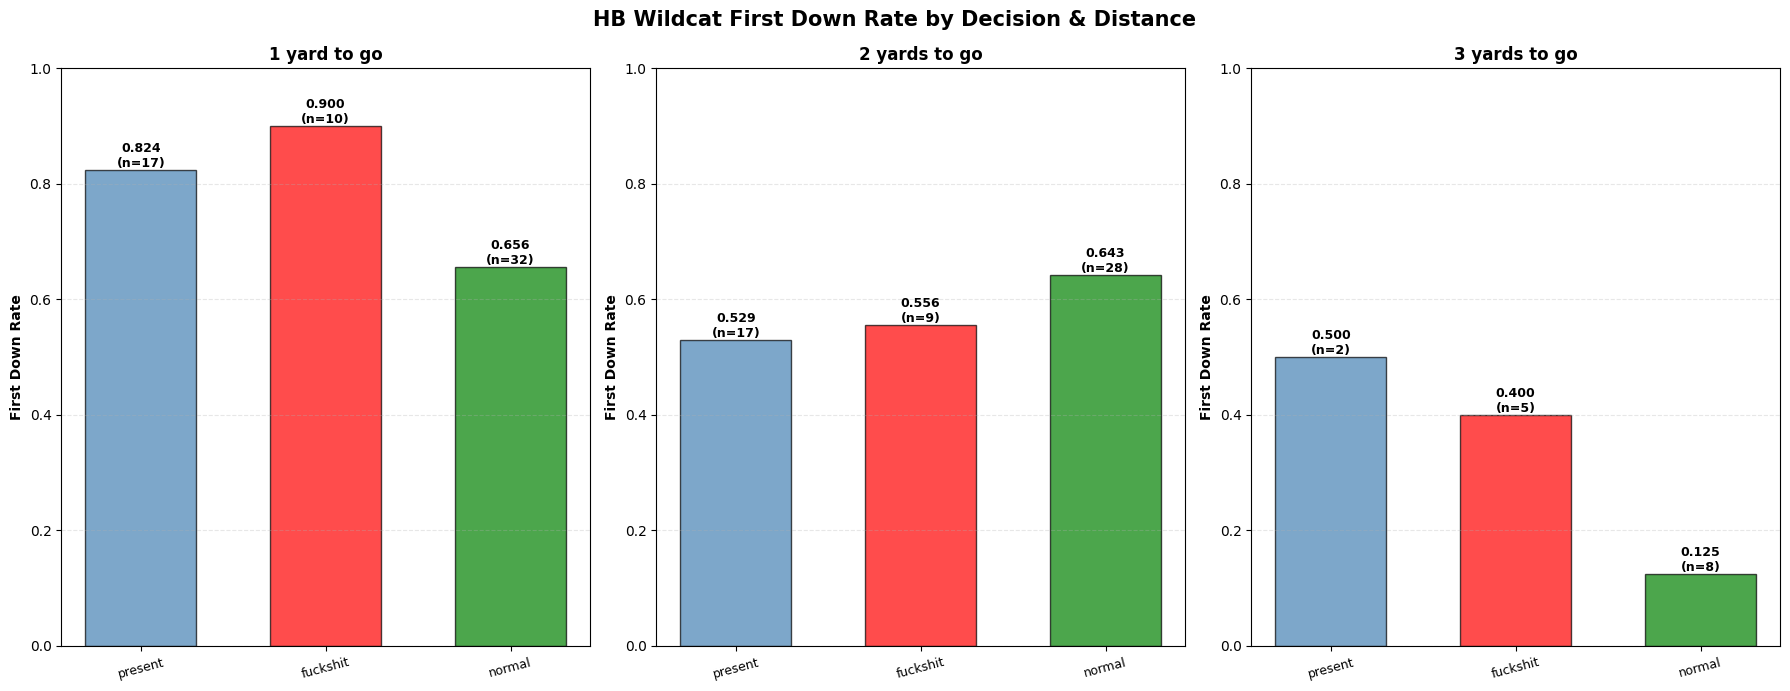

In [128]:
decisions = ['present', 'fuckshit', 'normal']
decision_colors = {'present': 'steelblue', 'fuckshit': 'red', 'normal': 'green'}

distances = [1, 2, 3]

fig, axes = plt.subplots(1, len(distances), figsize=(6 * len(distances), 7))
if len(distances) == 1:
    axes = [axes]

for ax, dist in zip(axes, distances):
    dist_df = combined_df[combined_df['distance'] == dist]
    valid_decisions = [d for d in decisions if len(dist_df[dist_df['wildcat_decision'] == d]) >= 1]

    for i, decision in enumerate(valid_decisions):
        group = dist_df[dist_df['wildcat_decision'] == decision]
        fd_rate = group['first_down_gained_numeric'].mean()
        n = len(group)

        ax.bar(i, fd_rate, width=0.6, color=decision_colors[decision], alpha=0.7, edgecolor='black')
        ax.text(i, fd_rate, f"{fd_rate:.3f}\n(n={n})",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(valid_decisions)))
    ax.set_xticklabels(valid_decisions, rotation=15, fontsize=9)
    ax.set_title(f'{dist} yard{"s" if dist > 1 else ""} to go', fontweight='bold', fontsize=12)
    ax.set_ylabel('First Down Rate', fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('HB Wildcat First Down Rate by Decision & Distance',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

from scipy import stats
import numpy as np

group1 = np.array([1]*5 + [0]*4)  # 14/26
group2 = np.array([1]*18 + [0]*10)  # 18/28

t_stat, p_value = stats.ttest_ind(group1, group2)

print(f"Group 1: {5/9:.3f} (n=26)")
print(f"Group 2: {18/28:.3f} (n=28)")
print(f"\nT-statistic: {t_stat:.3f}")
print(f"P-value:     {p_value:.3f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")


Group 1: 0.556 (n=26)
Group 2: 0.643 (n=28)

T-statistic: -0.458
P-value:     0.650
Significant: No (α=0.05)
